In [188]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [189]:
df = pd.read_csv('titanic.csv')
df.shape

(891, 12)

In [190]:
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]
df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


In [191]:
le = LabelEncoder()
df['gender'] = le.fit_transform(df.Sex)

In [192]:
X = df.drop(['Survived', 'Sex'], axis=1)
Y = df.Survived

In [193]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Pclass  891 non-null    int64  
 1   Age     714 non-null    float64
 2   Fare    891 non-null    float64
 3   gender  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [194]:
X.Age.fillna(X.Age.median(), inplace=True)

/tmp/ipython-input-3190736747.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X.Age.fillna(X.Age.median(), inplace=True)


In [195]:
X

,Pclass,Age,Fare,gender
0,3,22.0,7.2500,1
1,1,38.0,71.2833,0
2,3,26.0,7.9250,0
3,1,35.0,53.1000,0
4,3,35.0,8.0500,1
...,...,...,...,...
886,2,27.0,13.0000,1
887,1,19.0,30.0000,0
888,3,28.0,23.4500,0
889,1,26.0,30.0000,1


In [196]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Pclass  891 non-null    int64  
 1   Age     891 non-null    float64
 2   Fare    891 non-null    float64
 3   gender  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [197]:
Y

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [198]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.1)

In [199]:
X_train.shape

(801, 4)

In [200]:
X_test.shape

(90, 4)

In [201]:
model = DecisionTreeClassifier().fit(X_train, y_train)

In [202]:
model.score(X_test, y_test)

0.8

In [203]:
prediction = model.predict(X_test)
prediction

array([0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0])

In [204]:
# model.predict_proba(X_test)
y_test

,Survived
6,0
403,0
211,1
747,1
520,1
...,...
14,0
122,0
316,1
226,1


In [205]:
cm = confusion_matrix(y_test, prediction)
cm

array([[46,  8],
       [10, 26]])

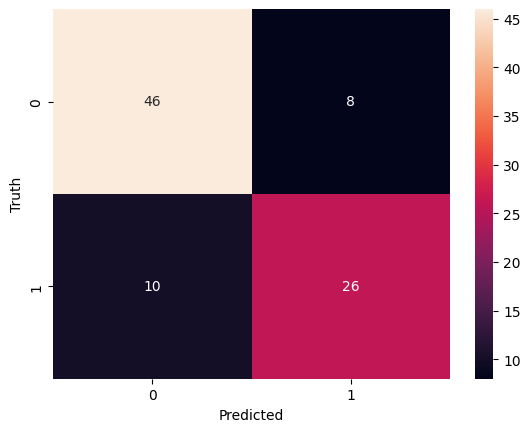

In [206]:
sns.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()